# NOAA High Resolution Rapid Refresh (HRRR)

## Using the Notebook
First we install any necessary packages. Please note that the following block of code only needs to be run if needed within a new workspace and that you may need to restart the kernel to use updated packages. The code block only needs to be run once for each AWS Sagemaker Studio profile.

In [ ]:
%pip -q install dask folium geopandas imageio ipywidgets matplotlib mapclassify pystac-client rioxarray tqdm

## HRRR Background (exceprt from the [NOAA HRRR stactools package docs](https://github.com/stactools-packages/noaa-hrrr))

The [NOAA HRRR dataset](https://www.nco.ncep.noaa.gov/pmb/products/hrrr/#CO)
is a continuously updated atmospheric forecast data product.

### Data structure

- There are two regions: CONUS and Alaska
- Every hour, new hourly forecasts are generated for many atmospheric attributes
  for each region
  - All hours (`00-23`) get an 18-hour forecast in the `conus` region
  - Forecasts are generated every three hours (`00`, `03`, `06`, etc) in the
    `alaska` region
  - On hours `00`, `06`, `12`, `18` a 48-hour forecast is generated
  - One of the products (`subh`) gets 15 minute forecasts (four per hour per
    attribute), but the sub-hourly forecasts are stored as layers within a
    single GRIB2 file for the forecast hour rather than in separate files.
- The forecasts are broken up into 4 products (`sfc`, `prs`, `nat`, `subh`),  
- Each GRIB2 file has hundreds to thousands of variables
- Each .grib2 file is accompanied by a .grib2.idx which has variable-level
  metadata including the starting byte for the data in that variable (useful
  for making range requests instead of reading the entire file) and some
  other descriptive metadata

### Summary of Considerations for Organizing STAC Metadata

After extensive discussions, we decided to organize the STAC metadata with
the following structure:

1. **Collections**: Separate collections for each region-product combination
    - regions: `conus` and `alaska`
    - products: `sfc`, `prs`, `nat`, and `subh`

2. **Items**: Each GRIB file in the archive is represented as an item with two assets:
    - `"grib"`: Contains the actual data.
    - `"index"`: The .grib2.idx sidecar file.

   Each GRIB file contains the forecasts for all of a product's variables for a
   particular forecast hour from a reference time, so you need to combine data
   from multiple items to construct a time series for a forecast. It uses the

   [`forecast` extension](https://github.com/stac-extensions/forecast) to
   organize the forecast attributes, notably the `forecast:horizon` and
  `forecast:reference_time` properties.

4. **`grib:layers`**: Within each `"grib"` asset, a `grib:layers` property details
   each layer's information, including description, units, and byte ranges.
   This enables applications to access specific parts of the GRIB2 files without
   downloading the entire file.

    - We intend to propose a `GRIB` STAC extension with the `grib:layers` property
      for storing byte-ranges after testing this specification out on other GRIB2
      datasets.
    - The layer-level metadata is worth storing in STAC because you can construct
      URIs for specific layers that GDAL can read using either `/vsisubfile` or
      `vrt://`:
      - `/vsisubfile/{start_byte}_{byte_size},/vsicurl/{grib_href}`
      - `vrt:///vsicurl/{grib_href}?bands={grib_message}`, where `grib_message` is
        the index of the layer within the GRIB2 file.
        - under the hood, GDAL's `vrt` driver is reading the sidecar .grib2.idx file
            and translating it into a `/vsisubfile` URI.


In [ ]:
import os
from datetime import datetime, timedelta

import geopandas as gpd
import pandas as pd
import pystac_client
import rioxarray
import xarray as xr
from pystac import Asset, Collection, ItemCollection
from tqdm.notebook import tqdm, trange

# disable some pesky GDAL warnings/messages
os.environ["CPL_LOG"] = "OFF"

### Querying the AWS STAC API with Pystac Client
Using the [Pystac Client](https://pystac-client.readthedocs.io/en/stable/) library we can query the AWS STAC API to access NOAA HRRR STAC items.

The data are organized in eight separate collections. One collection per **product** (`sfc`, `prs`, `nat`, `subh`) and **region** (conus or alaska) combination.

For this demonstration, we will look at variables in the `"noaa-hrrr-src-conus"` collection.

In [ ]:
API_ROOT_URL = "https://dev.asdi-catalog.org/"
COLLECTION_ID = "noaa-hrrr-sfc-conus"

client = pystac_client.Client.open(API_ROOT_URL)

collection = client.get_collection(COLLECTION_ID)
collection

### Forecast queries
A new forecast is generated every hour and the the STAC item metadata is uploaded to the STAC as the data land in the AWS bucket (`s3://noaa-hrrr-bdp-pds/`).
There is usually a ~one-hour lag between forecast model run and the data getting uploaded to S3.

An 18-hour forecast is generated every hour, but every 6 hours (00, 06, 12, 18) a 48-hour forecast is generated.
To get the most recent available 48-hour forecast, we can apply a filter to our STAC search that limits the results where the forecast horizon is 48 hours (`"forecast:horizon" == "PT48H")).

Once we have found the item for the most recent 48-hour forecast, we can load the full 48-hour forecast by running a search that limits the results to items where the forecast reference time matches the reference time from the item retrieved in the first query.

In [ ]:
# perform a search to get the full 48 hour forecast (plus the zero-hour forecast) for a point in time
now = datetime.now().replace(minute=0, second=0)

search = client.search(
    collections=COLLECTION_ID,
    sortby="datetime",
    filter={
        "op": "and",
        "args": [
            {
                "op": "eq",
                "args": [{"property": "forecast:horizon"}, "PT48H"]
            },
            {
                "op": "gte",
                "args": [
                    {"property": "forecast:reference_time"},
                    (now - timedelta(hours=6)).strftime("%Y-%m-%dT%H:%M:%SZ")
                ],
            },
        ],
    }
)

# get the forecast that was generated most recently
most_recent_48_hour_forecast_item = sorted(
    search.item_collection(),
    key=lambda item: datetime.strptime(
        item.properties["forecast:reference_time"], "%Y-%m-%dT%H:%M:%SZ"
    ),
    reverse=True
)[0]

# now search for all items with that reference time
search = client.search(
    collections="noaa-hrrr-sfc-conus",
    filter={
        "op": "eq",
        "args": [
            {"property": "forecast:reference_time"},
            most_recent_48_hour_forecast_item.properties["forecast:reference_time"]
        ]
    },
)

item_collection = search.item_collection()
print(f"retrieved {len(item_collection)} items")

The HRRR predictions are distributed in the GRIB2 format. GRIB2 files have many different layers encoded as "messages" that are strung together. Fortunately each GRIB file is accompanied by a .grib.idx index file that describes the byte ranges for each of the messages/layers. GDAL can perform targeted reads of the GRIB2 files if we use the `vrt://` syntax with a band index.

In [ ]:
# identify the grib:layers key for the wind speed variable
{key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items() if "WIND" in key}

In [ ]:
# function for generating a uri that GDAL can open using the /vsisubfile driver
def format_vrt_path(grib_href: str, grib_message: int) -> str:
    return f"vrt:///vsicurl/{grib_href}?bands={grib_message}"

# function to load a particular layer from all items into xarray and stack along the time dimension
def xarray_from_item_collection(item_collection: ItemCollection, grib_layer_key: str):
    item_layers = {}
    for item in item_collection:
        layer_info = item.assets["grib"].extra_fields["grib:layers"].get(grib_layer_key)
        if layer_info:
            vrt_path = format_vrt_path(item.assets["grib"].href, layer_info["grib_message"])
            arr = (
                rioxarray.open_rasterio(
                    vrt_path,
                    chunks={
                        "band": 1,
                        "x": -1,  # keep all x/y coordinates in the same chunk because GRIB files
                        "y": -1,  # do not have any spatial partitioning
                    },
                    use_idx="NO",
                )
                .squeeze()
                .assign_coords(
                    time=item.properties["datetime"],
                    reference_datetime=item.properties["forecast:reference_time"],
                ).expand_dims("time")
            )
            item_layers[item.id] = arr

    return xr.concat(item_layers.values(), dim="time").sortby("time").chunk(time=1)

In [ ]:
wind_ts = xarray_from_item_collection(item_collection, "WIND__10_m_above_ground__periodic_max")
wind_ts

## visualizing 48-hour forecast data


In [ ]:
# code for rendering gifs from xarray data
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import io
from IPython.display import Image


# Function to plot a single frame and return as a BytesIO object
def plot_frame(data, time_idx, title, vmin, vmax, cmap, units_label):
    fig, ax = plt.subplots(figsize=(7,5))
    im = ax.imshow(data.isel(time=time_idx), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_axis_off()

    # Adjust layout to reduce whitespace
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)
    
    # Main title at the top
    fig.suptitle(title, fontsize=12, y=0.92)

    # reference time coordinate at the bottom left
    fig.text(0.1, 0.05, f"reference time: {data.reference_datetime.values}", ha="left", fontsize=10)
    
    # forecast time coordinate at the bottom right
    fig.text(0.95, 0.05, f"forecast time: {data.time.values[time_idx]}", ha="right", fontsize=10)
    
    # Horizontal colorbar below the image
    cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.03])
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(units_label, fontsize=10, labelpad=3)
    cbar.ax.xaxis.set_label_position("top")
    
    # Progress bar at the very bottom
    total_frames = data.sizes["time"]
    progress = (time_idx + 1) / total_frames
    progress_bar = plt.Rectangle((0.1, 0.02), progress * 0.8, 0.02, transform=fig.transFigure, color="blue")
    fig.patches.append(progress_bar)
    
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)
    buf.seek(0)
    return buf

def render_gif(data: xr.DataArray, title: str, cmap: str, units_label: str, vmin: float = None, vmax: float = None):
    if vmin == None:
        vmin = data.quantile(0.01).item()
    if vmax == None:
      vmax = data.quantile(0.99).item()

    # Create frames in memory
    frames = []
    for t in trange(data.sizes["time"]):
        frame = plot_frame(data, t, title, vmin, vmax, cmap, units_label)
        frames.append(imageio.imread(frame))
    
    # Create a GIF in memory
    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, frames, format="GIF", duration=0.5, loop = 0)
    gif_bytes.seek(0)
    
    return gif_bytes.read()

  0%|          | 0/49 [00:00<?, ?it/s]

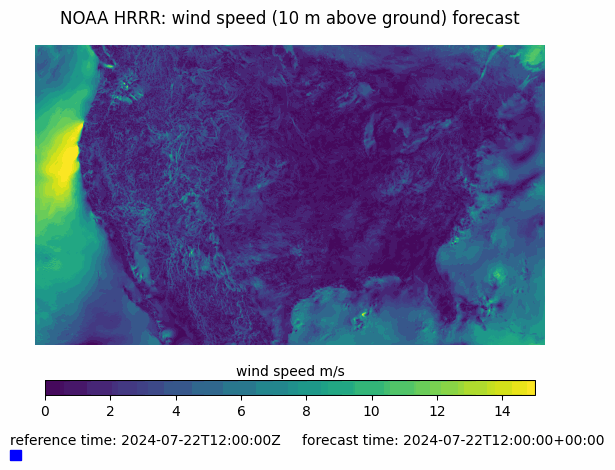

In [22]:
Image(
    render_gif(
        data=wind_ts,
        title="NOAA HRRR: wind speed (10 m above ground) forecast",
        cmap="viridis",
        units_label="wind speed m/s",
        vmin=0,
        vmax=15
    )
)

## More visualization examples
To identify a particular variable of interest you can browse the item-assets metadata to find the specific `grib:layers` key that you need.

In [23]:
{key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items() if "DSWRF" in key}

{'DSWRF__surface__point_in_time': {'unit': 'W/m^2',
  'level': 'surface',
  'variable': 'DSWRF',
  'description': 'Downward Short-Wave Radiation  Flux',
  'forecast_layer_type': 'point_in_time'}}

In [ ]:
solar_ts = xarray_from_item_collection(item_collection, "DSWRF__surface__point_in_time")
Image(
    render_gif(
        data=solar_ts,
        title="NOAA HRRR: downward short-wave radiation flux",
        cmap="rainbow",
        units_label="W/m^2",
        vmin=0,
        vmax=1000
    )
)

In [24]:
{key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items() if "PRATE" in key}

{'PRATE__surface__point_in_time': {'unit': 'kg/m^2/s',
  'level': 'surface',
  'variable': 'PRATE',
  'description': 'Precipitation Rate',
  'forecast_layer_type': 'point_in_time'}}

In [ ]:
precip_rate_ts = xarray_from_item_collection(item_collection, "PRATE__surface__point_in_time")
Image(
    render_gif(
        data=precip_rate_ts,
        title="NOAA HRRR: precipitation rate",
        cmap="PuBu",
        units_label="kg / m^2 / s",
        vmin=0,
        vmax=0.001
    )
)


In [25]:
{key: info for key, info in collection.ext.item_assets["grib"].properties["grib:layers"].items() if "APCP" in key}

{'APCP__surface__periodic_acc': {'unit': 'kg/m^2',
  'level': 'surface',
  'variable': 'APCP',
  'description': 'Total Precipitation',
  'forecast_layer_type': 'periodic_summary'},
 'APCP__surface__cumulative_acc': {'unit': 'kg/m^2',
  'level': 'surface',
  'variable': 'APCP',
  'description': 'Total Precipitation',
  'forecast_layer_type': 'cumulative_summary'}}

In [ ]:
precip_acc_ts = xarray_from_item_collection(item_collection, "APCP__surface__cumulative_acc")
Image(
    render_gif(
        data=precip_acc_ts,
        title="NOAA HRRR: precipitation accumulation",
        cmap="Blues",
        units_label="kg / m^2",
        vmin=0,
        vmax=60
    )
)